In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error,mean_absolute_error, r2_score
import numpy as np

#load dataset
data = pd.read_excel("../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025


df.set_index('Date', inplace=True)
df = df.sort_values('Date')

# Optional but recommended
#df = df.asfreq('6MS')

ts = df['Sown_Extent_Total']

# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

In [2]:
# Multiplicative
model_mul = ExponentialSmoothing(
    train,
    trend='mul',
    seasonal='mul',
    seasonal_periods=2
).fit()



C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [3]:
print(model_mul.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:        Sown_Extent_Total   No. Observations:                   53
Model:             ExponentialSmoothing   SSE                   205643906436.028
Optimized:                         True   AIC                           1182.193
Trend:                   Multiplicative   BIC                           1194.015
Seasonal:                Multiplicative   AICC                          1185.466
Seasonal Periods:                     2   Date:                 Tue, 02 Jun 2026
Box-Cox:                          False   Time:                         12:30:09
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1576250                alpha                 True
smoothing_trend          

In [4]:
forecast_mul = model_mul.forecast(len(test))
forecast_mul

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    665887.805073
54    383369.712716
55    670969.417624
56    386295.335214
57    676089.809660
58    389243.284116
59    681249.277120
60    392213.729802
61    686448.118202
62    395206.843952
63    691686.633379
64    398222.799558
65    696965.125417
66    401261.770930
dtype: float64

In [5]:
rmse_mul = np.sqrt(mean_squared_error(test, forecast_mul))
mape_mul = mean_absolute_percentage_error(test, forecast_mul) * 100
mae_mul = mean_absolute_error(test, forecast_mul)
r2 = r2_score(test, forecast_mul)

In [6]:
print("\nMultiplicative Model")

print(f"RMSE : {rmse_mul:.2f}")
print(f"MAPE : {mape_mul:.2f}")
print(f"MAE : {mae_mul:.2f}")
print(f"R²   : {r2:.4f}")


Multiplicative Model
RMSE : 98317.19
MAPE : 15.29
MAE : 93998.41
R²   : 0.6087


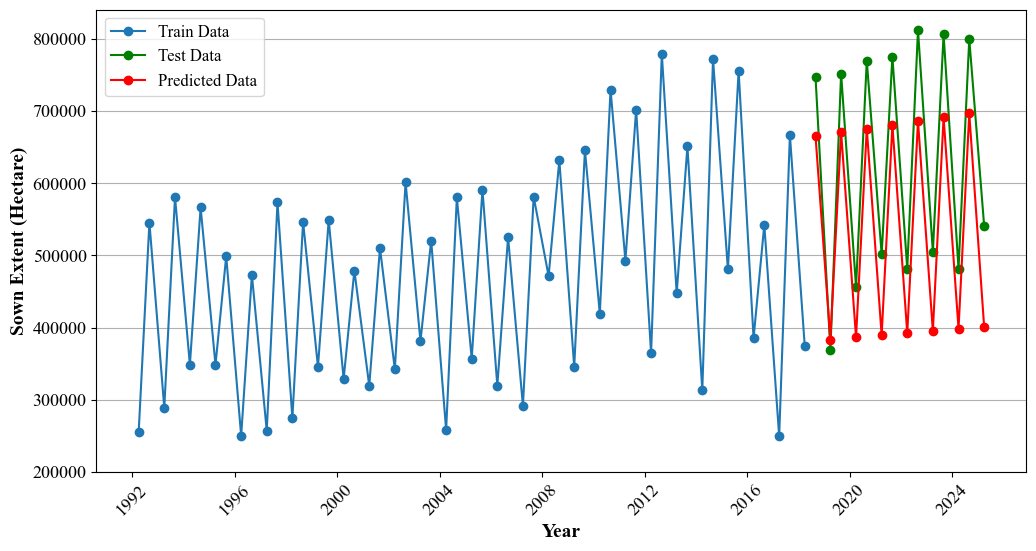

In [7]:
#Plot Forecast
plt.figure(figsize=(12,6))


plt.plot(train.index, train, label="Train Data",marker="o",linewidth=1.5)
plt.plot(test.index, test, label="Test Data", color="green",marker="o",linewidth=1.5)
plt.plot(test.index, forecast_mul, label="Predicted Data", color="red",marker="o",linewidth=1.5)

plt.legend(prop={'size': 12, 'family':'Times New Roman'}  )

plt.ylim(200000,)


plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Sown Extent (Hectare)",fontsize=14,fontweight='bold',fontname='Times New Roman')

plt.grid(axis='y')
plt.xticks(rotation=45)

plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

In [8]:
residuals = model_mul.resid

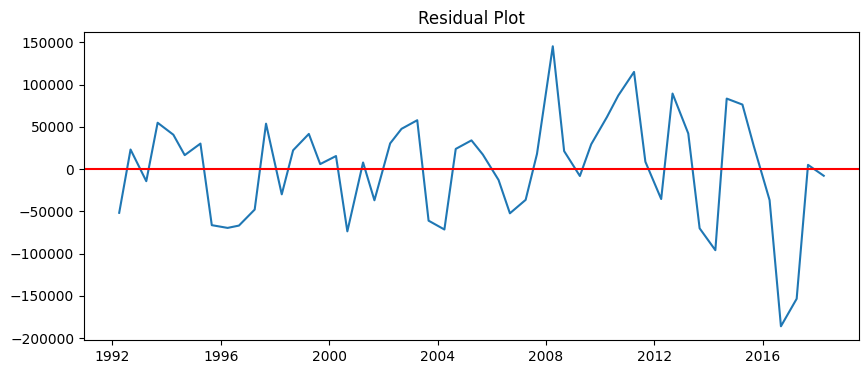

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(y=0, color='red')
plt.title("Residual Plot")
plt.show()

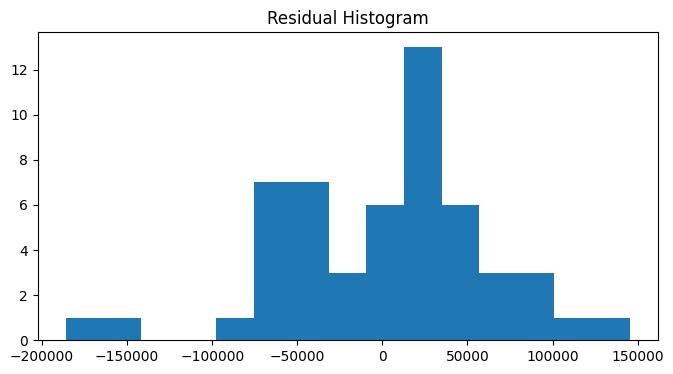

In [10]:
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=15)
plt.title("Residual Histogram")
plt.show()

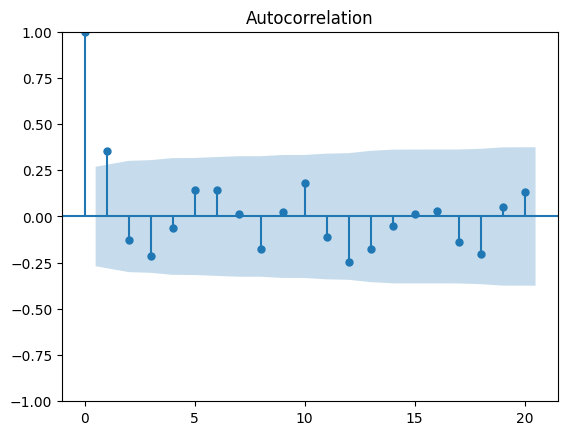

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=20)
plt.show()

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb)

      lb_stat  lb_pvalue
10  17.728979   0.059711


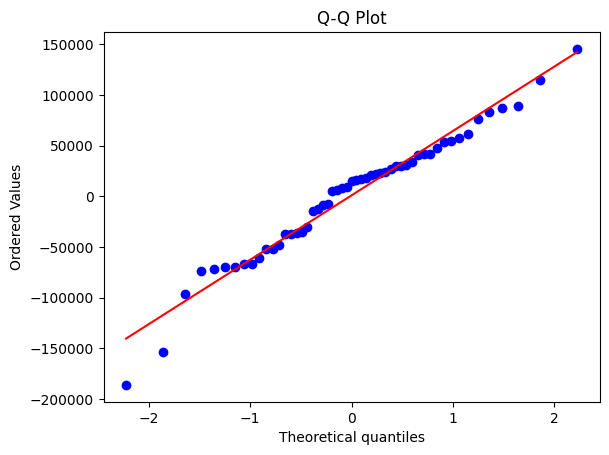

In [13]:
from scipy import stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()